# Seed Inisialization

# 🚀 0. SETUP PROJECT

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# install library penting
!pip install nibabel pydicom matplotlib numpy tqdm
!pip install monai

In [3]:
import torch
import numpy as np
import random
import monai

# 🔒 MENGUNCI (GLOBAL SEED)
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
monai.utils.set_determinism(seed=seed)
print("✅ Reproducibility Seed 42 Locked!")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ Reproducibility Seed 42 Locked!


# 📦 1. UNZIP DATA

In [4]:
import zipfile
import os

DATA_DIR = "processed"

# Lokasi SSD Colab Cepat (Untuk Load Inference / Baca Model)
TEMP_MODEL_DIR = "/content"

# Lokasi Asuransi Google Drive (JANGAN LUPA DIEDIT)
GDRIVE_MODEL_DIR = "/content/drive/MyDrive/IDSC/Ex3"

# Bikin folder otomatis kalau di GDrive bila beluma ada
os.makedirs(GDRIVE_MODEL_DIR, exist_ok=True)

zip_path = "/content/myocardial-perfusion-scintigraphy-image-database-1.0.0.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extract selesai")

✅ Extract selesai


# 📂 2. DEFINE PATH

In [5]:
base_path = "/content/data/myocardial-perfusion-scintigraphy-image-database-1.0.0"

# cek apakah nested
if len(os.listdir(base_path)) == 1:
    base_path = os.path.join(base_path, os.listdir(base_path)[0])

print("Base path:", base_path)

dicom_path = os.path.join(base_path, "DICOM")
mask_path  = os.path.join(base_path, "NIfTI")

print("DICOM:", dicom_path)
print("MASK :", mask_path)

Base path: /content/data/myocardial-perfusion-scintigraphy-image-database-1.0.0
DICOM: /content/data/myocardial-perfusion-scintigraphy-image-database-1.0.0/DICOM
MASK : /content/data/myocardial-perfusion-scintigraphy-image-database-1.0.0/NIfTI


# 🔍 3. CEK DATA

In [6]:
print("Sample DICOM:", os.listdir(dicom_path)[:5])
print("Sample MASK :", os.listdir(mask_path)[:5])

Sample DICOM: ['1.2.840.4267.32.85256219619375470646286639294258101763.dcm', '1.2.840.4267.32.271899686180980420863709160860895161350.dcm', '1.2.840.4267.32.270294565345733831828857310295354635209.dcm', '1.2.840.4267.32.71424296192740438472473806333747178689.dcm', '1.2.840.4267.32.319290549953534944045500467871458721511.dcm']
Sample MASK : ['1.2.840.4267.32.172126483870960686167898548367811174108_mask.nii.gz', '1.2.840.4267.32.212981937478866931016388881866193176623_mask.nii.gz', '1.2.840.4267.32.6282692783898975606278220787719726349_mask.nii.gz', '1.2.840.4267.32.198909662352645761702370624797276832408_mask.nii.gz', '1.2.840.4267.32.269418337391793402596164133173260566277_mask.nii.gz']


# 🫀 4. VISUALISASI MASK

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


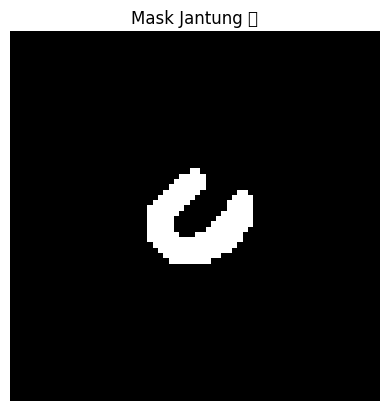

In [7]:
import nibabel as nib
import matplotlib.pyplot as plt

mask_files = [f for f in os.listdir(mask_path) if f.endswith((".nii.gz", ".nii"))]

mask_file = mask_files[0]
mask = nib.load(os.path.join(mask_path, mask_file)).get_fdata()

slice_idx = mask.shape[2] // 2

plt.imshow(mask[:, :, slice_idx], cmap="gray")
plt.title("Mask Jantung 🫀")
plt.axis("off")
plt.show()

# 🧠 5. LOAD DICOM → 3D VOLUME

In [8]:
import pydicom
import numpy as np

def load_dicom_series(folder_path):
    slices = []

    for file in os.listdir(folder_path):
        if file.endswith(".dcm"):
            dcm = pydicom.dcmread(os.path.join(folder_path, file))
            slices.append(dcm.pixel_array)

    slices = sorted(slices, key=lambda x: np.mean(x))  # simple sort

    volume = np.stack(slices, axis=-1)

    return volume

# ambil 1 sample
# dicom_files = os.listdir(dicom_path) # No longer needed if dicom_path is the target folder
# sample_folder = os.path.join(dicom_path, dicom_files[0]) # This caused the error

volume = load_dicom_series(dicom_path) # Pass the dicom_path directory directly

print("Volume shape:", volume.shape)

Volume shape: (50, 70, 70, 103)


# 🫀 6. VISUALISASI IMAGE

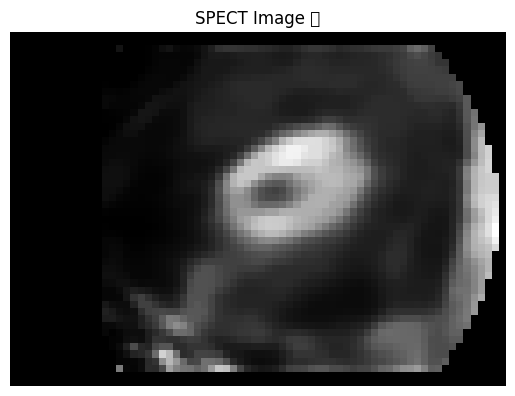

In [9]:
slice_idx = volume.shape[2] // 2
frame_idx = volume.shape[3] // 2 # Tambahkan indeks untuk memilih frame spesifik

plt.imshow(volume[:, :, slice_idx, frame_idx], cmap="gray") # Akses slice 2D yang benar
plt.title("SPECT Image 🫀")
plt.axis("off")
plt.show()

# 🔗 7. MATCH IMAGE

In [10]:
mask_files = sorted([f for f in os.listdir(mask_path) if f.endswith((".nii.gz", ".nii"))])
dicom_folders = sorted(os.listdir(dicom_path))

print("Jumlah mask :", len(mask_files))
print("Jumlah dicom:", len(dicom_folders))

Jumlah mask : 100
Jumlah dicom: 103


# 💾 8. SAVE CLEAN DATA

In [11]:
valid_pairs = []

for mask_file in sorted(os.listdir(mask_path)):
    id_base = mask_file.replace("_mask.nii.gz", "").replace("_mask.nii", "")
    dicom_file = id_base + ".dcm"

    if dicom_file in sorted(os.listdir(dicom_path)):
        valid_pairs.append((dicom_file, mask_file))

print(f"✅ Total Daftar Hadir Aman Terdali: {len(valid_pairs)}")


print("Valid pairs:", len(valid_pairs))

✅ Total Daftar Hadir Aman Terdali: 100
Valid pairs: 100


In [12]:
def normalize(volume):
    volume = volume.astype("float32")
    volume = (volume - np.mean(volume)) / np.std(volume)
    return volume

In [13]:
import scipy.ndimage as ndimage

def resize_volume(img, target_shape=(96,96,96)):
    factors = (
        target_shape[0] / img.shape[0],
        target_shape[1] / img.shape[1],
        target_shape[2] / img.shape[2]
    )
    img = ndimage.zoom(img, factors, order=1)
    return img

In [14]:
import numpy as np
import os
import pydicom
import nibabel as nib

save_path = "/content/processed"
os.makedirs(save_path, exist_ok=True)

# 🧹 Sapu bersih folder processed/ biar file bengkok lu kemaren musnah
for file_name in os.listdir(save_path):
    os.remove(os.path.join(save_path, file_name))

# ⚙️ Operasi Pelurusan dan Pembesaran 100 Pasien
for i, (dicom_file_name, mask_file_name) in enumerate(valid_pairs):
    dicom_full_path = os.path.join(dicom_path, dicom_file_name)
    mask_full_path = os.path.join(mask_path, mask_file_name)

    # 1. Sedot Data Murni dari Harddisk
    image = pydicom.dcmread(dicom_full_path).pixel_array
    mask_data = nib.load(mask_full_path).get_fdata()

    # MURNI TRANSPOSE 2, 1, 0)
    # Menyamakan format (Z, Y, X) jadi (X, Y, Z) biar orientasinya kembar identik

    image = np.transpose(image, (2, 1, 0))

    # 3. Mesin Resize Auto-Fit (Sekarang narik organ dari sudut pandang yang sejajar!)
    image = resize_volume(image, target_shape=(96, 96, 96))
    mask_data = resize_volume(mask_data, target_shape=(96, 96, 96))

    # 4. Standarisasi Biner Kunci Jawaban
    mask_data = (mask_data > 0.5).astype(np.float32)

    # 5. Save dan segel ke folder processed/
    np.save(os.path.join(save_path, dicom_file_name.replace(".dcm", ".npy")), image)
    np.save(os.path.join(save_path, mask_file_name.replace(".nii.gz", ".npy").replace(".nii", ".npy")), mask_data)

print(f"✅ {len(valid_pairs)} data pairs processed and saved to {save_path} for training")


✅ 100 data pairs processed and saved to /content/processed for training


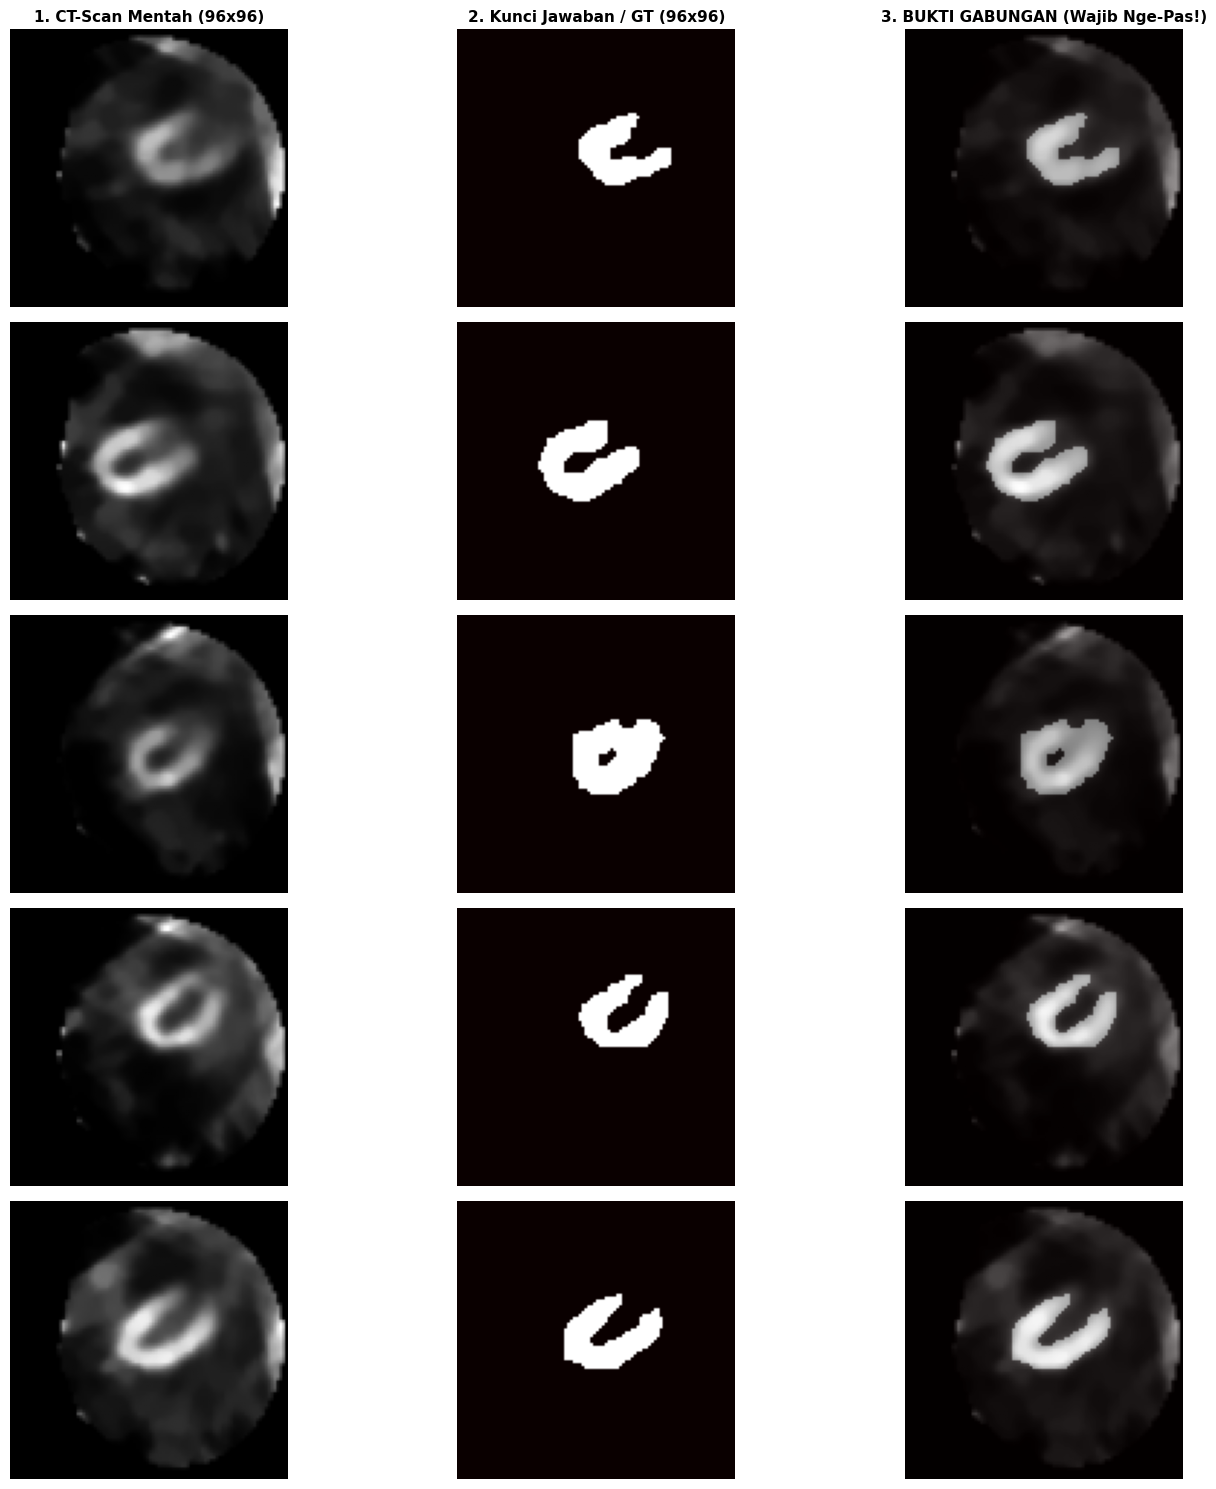

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Total pasien yang mau di-sweeping (Bisa lu ganti jadi 10 kalau kurang puas)
num_samples = 5

z = 48

plt.figure(figsize=(15, 3 * num_samples))

for i in range(num_samples):
    pasien_dicom = valid_pairs[i][0].replace(".dcm", ".npy")
    pasien_mask = valid_pairs[i][1].replace(".nii.gz", ".npy").replace(".nii", ".npy")

    # Ambil file wujud NumPy langsung dari dalem brankas hasil karya mesin Resize lu
    img_bersih = np.load(os.path.join("processed", pasien_dicom))
    mask_bersih = np.load(os.path.join("processed", pasien_mask))

    # 1. CT Scan Asli (Udah Dilurusin & Di-Resize)
    plt.subplot(num_samples, 3, i * 3 + 1)
    if i == 0: plt.title("1. CT-Scan Mentah (96x96)", fontsize=11, fontweight='bold')
    plt.imshow(img_bersih[:, :, z], cmap='gray')
    plt.ylabel(f"Pasien {i+1}", fontsize=12, fontweight='bold') # Kasi Label Nama di Kiri
    plt.axis("off")

    # 2. Kunci Jawaban Dokter (Masking)
    plt.subplot(num_samples, 3, i * 3 + 2)
    if i == 0: plt.title("2. Kunci Jawaban / GT (96x96)", fontsize=11, fontweight='bold')
    plt.imshow(mask_bersih[:, :, z], cmap='hot')
    plt.axis("off")

    # 3. PEMBUKTIAN OVERLAY GABUNGAN
    plt.subplot(num_samples, 3, i * 3 + 3)
    if i == 0: plt.title("3. BUKTI GABUNGAN (Wajib Nge-Pas!)", fontsize=11, fontweight='bold')
    plt.imshow(img_bersih[:, :, z], cmap='gray')
    plt.imshow(mask_bersih[:, :, z], cmap='hot', alpha=0.4) # Kunci jawaban dibikin transparan
    plt.axis("off")

plt.tight_layout()
plt.show()


In [16]:
from sklearn.model_selection import train_test_split
dev_pairs, test_pairs = train_test_split(
    valid_pairs,
    test_size=0.20,      # 20 Pasien masuk karantina Test Akhir
    random_state=42      # Kunci gembok algoritma pengocokan (Seed)
)
print(f"🧬 Development Set (Untuk 5-Fold Training) : {len(dev_pairs)} Pasien")
print(f"🔐 Hidden Test Set (Untuk Pembuktian Ensemble)   : {len(test_pairs)} Pasien")

🧬 Development Set (Untuk 5-Fold Training) : 80 Pasien
🔐 Hidden Test Set (Untuk Pembuktian Ensemble)   : 20 Pasien


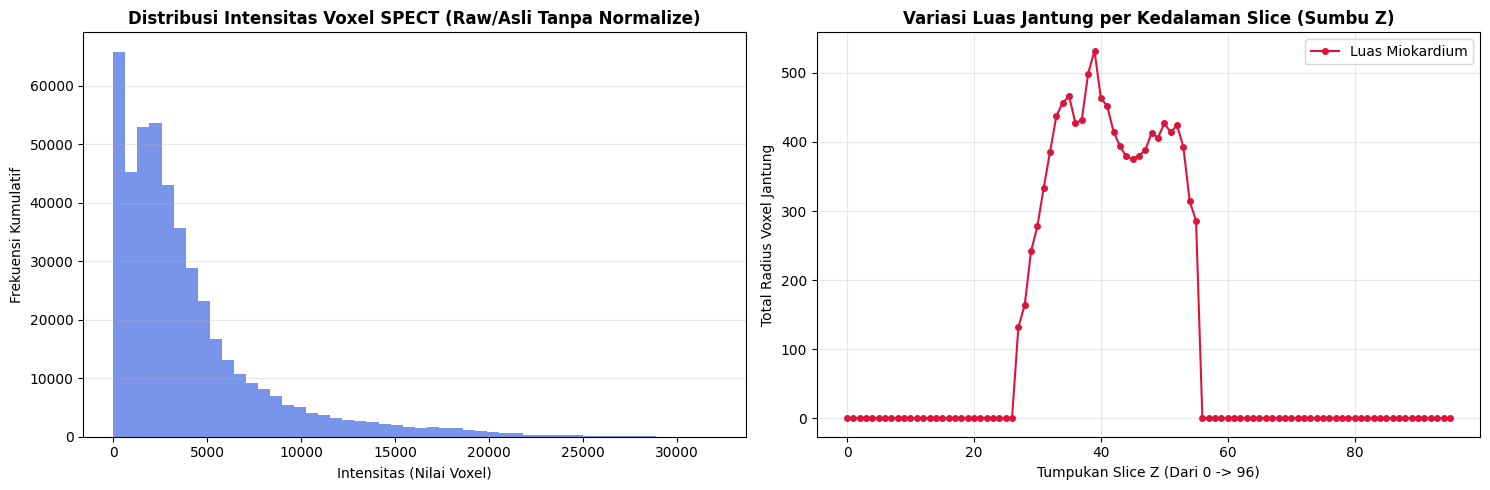

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Nyomot 1 pasien
sample_dicom = valid_pairs[0][0].replace(".dcm", ".npy")
sample_mask = valid_pairs[0][1].replace(".nii.gz", ".npy").replace(".nii", ".npy")

img_vol = np.load(os.path.join("processed", sample_dicom))  # Dada Asli
mask_vol = np.load(os.path.join("processed", sample_mask)) # Label Ground Truth

plt.figure(figsize=(15, 5))

# 📉 GRAFIK 1: DISTRIBUSI INTENSITAS VOXEL
plt.subplot(1, 2, 1)
# Sortir hampa Background murni (-ve) biar puncak kurva ga gepeng
voxel_intensities = img_vol[img_vol > img_vol.min()].flatten()
plt.hist(voxel_intensities, bins=50, color='royalblue', alpha=0.7)
plt.title("Distribusi Intensitas Voxel SPECT (Raw/Asli Tanpa Normalize)", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas (Nilai Voxel)")
plt.ylabel("Frekuensi Kumulatif")
plt.grid(axis='y', alpha=0.3)

# 📉 GRAFIK 2: VARIASI LUAS JANTUNG ANTAR SLICE (Kedalaman)
plt.subplot(1, 2, 2)
# Hitung tumpukan piksel bernilai '1' pada irisan sumbu Z satu per satu
slice_areas = [np.sum(mask_vol[:, :, z]) for z in range(mask_vol.shape[2])]
plt.plot(range(mask_vol.shape[2]), slice_areas, color='crimson', marker='o', markersize=4, label='Luas Miokardium')
plt.title("Variasi Luas Jantung per Kedalaman Slice (Sumbu Z)", fontsize=12, fontweight='bold')
plt.xlabel("Tumpukan Slice Z (Dari 0 -> 96)")
plt.ylabel("Total Radius Voxel Jantung")
plt.legend()
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()


Dataset Summary:
- Total DICOM: 103
- Total Mask: 100
- Valid pairs: 100

Preprocessing:
- Normalization (z-score)
- Resizing to 96x96x96
- Data split: 80/20

Notes:
- 3 DICOM without segmentation removed

# Augmentation

In [18]:
import numpy as np
import monai
from monai.transforms import (
    Compose, RandRotate90d, RandAffined, ToTensord, RandZoomd,
    RandGaussianNoised, RandFlipd, RandGaussianSmoothd, Rand3DElasticd
)

# 1. Kunci Utama: Transformasi Custom peload .npy & Z-Score Scaling
class LoadAndNormalizeNpy:
    def __call__(self, data):
        d = dict(data)
        img = np.load(d["image"]).astype(np.float32)
        label = np.load(d["label"]).astype(np.float32)

        # Z-Score Normalization
        img = (img - img.mean()) / (img.std() + 1e-8)

        # Tambah Channel Dimensi )
        d["image"] = np.expand_dims(img, axis=0)
        d["label"] = np.expand_dims(label, axis=0)
        return d

# 2. PABRIK AUGMENTASI
train_transforms = Compose([
    LoadAndNormalizeNpy(),

    # 1. Spasial Makro (Posisi Tubuh Pasien Nyender di Ranjang)
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(0, 1)),
    RandFlipd(keys=["image", "label"], prob=0.2, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.2, spatial_axis=1),

    # 2. Spasial Mikro (Pembeda Otot Jantung & Jarak Nafas)
    RandAffined(keys=["image", "label"], prob=0.4, translate_range=4, rotate_range=3.14/15, scale_range=(0.95, 1.05)),
    RandZoomd(keys=["image", "label"], prob=0.3, min_zoom=0.95, max_zoom=1.05, mode=("trilinear", "nearest")),
    # Rand3DElasticd(keys=["image", "label"], prob=0.2, sigma_range=(5, 7), magnitude_range=(50, 150)), # Melarin otot kenyal

    # 3. Kualitas Sensor Kamera Nuklir (Simulasi Mesin RS Rusak / Pasien Bergerak Tiba2)
    RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.05), # Bintik radiasi
    RandGaussianSmoothd(keys=["image"], sigma_x=(0.25, 1.0), sigma_y=(0.25, 1.0), sigma_z=(0.25, 1.0), prob=0.2), # Gambar kabur
    ToTensord(keys=["image", "label"])
])

# 3. PABRIK VALIDASI (Ujian Murni tanpa muter gambar)
val_transforms = Compose([
    LoadAndNormalizeNpy(),
    ToTensord(keys=["image", "label"])
])


## Alpha 2 Train

In [19]:
import torch
import numpy as np
from sklearn.model_selection import KFold
from monai.networks.nets import UNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import Compose, ToTensord
from monai.data import Dataset, DataLoader
import os
import gc

device = "cuda" if torch.cuda.is_available() else "cpu"

# KONFIGURASI K-FOLD
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

max_epochs = 200
val_interval = 2

fold_results = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(dev_pairs)):
    print(f"\n{'='*50}")
    print(f"🔄 FOLD {fold + 1}/{num_folds}")
    print(f"{'='*50}")
    print(f"   Train: {len(train_idx)} pasien | Val: {len(val_idx)} pasien")

    # Pecah data berdasarkan indeks fold
    train_fold_pairs = [dev_pairs[i] for i in train_idx]
    val_fold_pairs = [dev_pairs[i] for i in val_idx]

    # Bangun file list MONAI (DENGAN PEMBASMI NAMA GANDA)
    train_files = [{"image": os.path.join("processed", f[0].replace(".dcm", ".npy")),
                    "label": os.path.join("processed", f[1].replace(".nii.gz", ".npy").replace(".nii", ".npy"))}
                   for f in train_fold_pairs]

    val_files = [{"image": os.path.join("processed", f[0].replace(".dcm", ".npy")),
                  "label": os.path.join("processed", f[1].replace(".nii.gz", ".npy").replace(".nii", ".npy"))}
                 for f in val_fold_pairs]

    # Dataset & Loader
    train_ds = Dataset(data=train_files, transform=train_transforms)
    val_ds = Dataset(data=val_files, transform=val_transforms)
    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

    # 🧠 Model BARU dari NOL setiap Fold (Fresh Weights!)
    model = UNETR(
        in_channels=1, out_channels=1,
        img_size=(96, 96, 96),
        feature_size=16, hidden_size=768, mlp_dim=3072,
        num_heads=12, norm_name="instance",
        res_block=True, dropout_rate=0.0,
    ).to(device)

    if torch.cuda.device_count() > 1:
        print(f"🚀 Gunakan {torch.cuda.device_count()} GPU sekaligus!")
        model = torch.nn.DataParallel(model)  # Ini mantra buat mbelah kerjaan

    model = model.to(device)

    loss_function = DiceCELoss(
    to_onehot_y=False,
    sigmoid=True,
    squared_pred=True,
    lambda_dice=1.0,     # 100% Peduli Bentuk Organ
    lambda_ce=0.5        # 50% Peduli Background Item
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    # 🔧 LR SCHEDULER (Cosine Annealing - Pengerem Otomatis)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)

    dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

    best_metric = -1
    best_metric_epoch = -1

    train_loss_history = []
    val_dice_history = []
    val_epoch_history = []

    for epoch in range(max_epochs):
        # [TRAINING]
        model.train()
        epoch_loss = 0
        step = 0
        for batch_data in train_loader:
            step += 1
            inputs = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= step
        train_loss_history.append(epoch_loss)

        # Step LR Scheduler setiap epoch
        scheduler.step()

        # [VALIDATION]
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs = val_data["image"].to(device)
                    val_labels = val_data["label"].to(device)
                    val_outputs = model(val_inputs)
                    val_outputs = (val_outputs.sigmoid() > 0.5).float()
                    dice_metric(y_pred=val_outputs, y=val_labels)

                metric = dice_metric.aggregate().item()
                dice_metric.reset()
                val_dice_history.append(metric)
                val_epoch_history.append(epoch + 1)

                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    # 1. Simpan Lokal
                    torch.save(model.state_dict(), os.path.join(TEMP_MODEL_DIR, f"fold{fold+1}_best.pth"))
                    # 2. Asuransi G-Drive
                    torch.save(model.state_dict(), os.path.join(GDRIVE_MODEL_DIR, f"fold{fold+1}_best.pth"))

                # Print setiap 10 epoch biar log
                if (epoch + 1) % 10 == 0:
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"   Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f} | Dice: {metric:.4f} | LR: {current_lr:.2e}")

        # Jaga memory leak
        gc.collect()
        torch.cuda.empty_cache()

    fold_results[fold + 1] = {
        "best_dice": best_metric,
        "best_epoch": best_metric_epoch,
        "train_loss": train_loss_history,
        "val_dice": val_dice_history,
        "val_epochs": val_epoch_history
    }
    print(f"   ✅ Fold {fold+1} Selesai! Best Dice: {best_metric:.4f} di Epoch {best_metric_epoch}")

# RANGKUMAN SELURUH FOLD
print(f"\n{'='*50}")
print("📊 RANGKUMAN 5-FOLD CROSS VALIDATION")
print(f"{'='*50}")
all_scores = []
for fold_num, result in fold_results.items():
    print(f"   Fold {fold_num}: Dice = {result['best_dice']:.4f} (Epoch {result['best_epoch']})")
    all_scores.append(result['best_dice'])
mean_dice = np.mean(all_scores)
std_dice = np.std(all_scores)
print(f"\n   🏆 RATA-RATA DICE: {mean_dice:.4f} ± {std_dice:.4f}")



🔄 FOLD 1/5
   Train: 64 pasien | Val: 16 pasien
   Epoch  10 | Loss: 0.8341 | Dice: 0.7331 | LR: 9.94e-05
   Epoch  20 | Loss: 0.7197 | Dice: 0.8172 | LR: 9.76e-05
   Epoch  30 | Loss: 0.6928 | Dice: 0.8817 | LR: 9.46e-05
   Epoch  40 | Loss: 0.6142 | Dice: 0.8516 | LR: 9.05e-05
   Epoch  50 | Loss: 0.5528 | Dice: 0.9027 | LR: 8.55e-05
   Epoch  60 | Loss: 0.5028 | Dice: 0.9123 | LR: 7.96e-05
   Epoch  70 | Loss: 0.4716 | Dice: 0.9178 | LR: 7.30e-05
   Epoch  80 | Loss: 0.3969 | Dice: 0.9160 | LR: 6.58e-05
   Epoch  90 | Loss: 0.3656 | Dice: 0.9187 | LR: 5.82e-05
   Epoch 100 | Loss: 0.3603 | Dice: 0.9152 | LR: 5.05e-05
   Epoch 110 | Loss: 0.3449 | Dice: 0.9196 | LR: 4.28e-05
   Epoch 120 | Loss: 0.3221 | Dice: 0.9205 | LR: 3.52e-05
   Epoch 130 | Loss: 0.3103 | Dice: 0.9231 | LR: 2.80e-05
   Epoch 140 | Loss: 0.2792 | Dice: 0.9238 | LR: 2.14e-05
   Epoch 150 | Loss: 0.3047 | Dice: 0.9188 | LR: 1.55e-05
   Epoch 160 | Loss: 0.2720 | Dice: 0.9227 | LR: 1.05e-05
   Epoch 170 | Loss: 0.

# Grafik Loss Dan Dice

🖨️ Mencetak Kurva


/tmp/ipykernel_73193/905254815.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(f"/content/Pilar2_Curve_Fold{fold_num}.png", dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


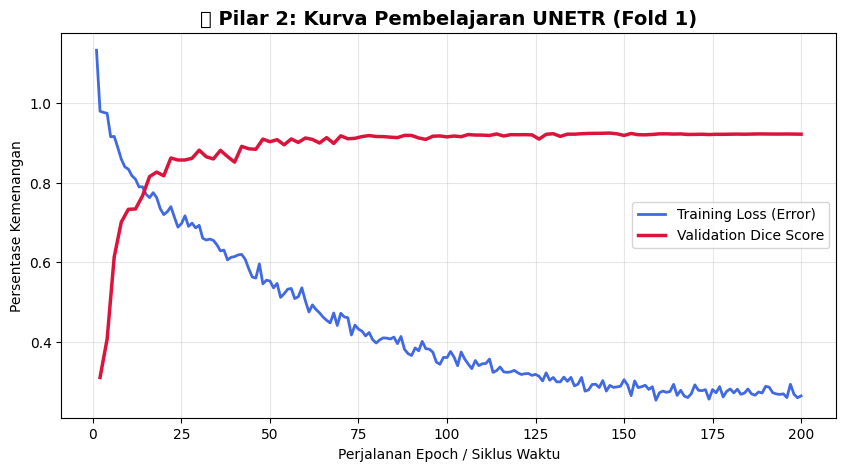

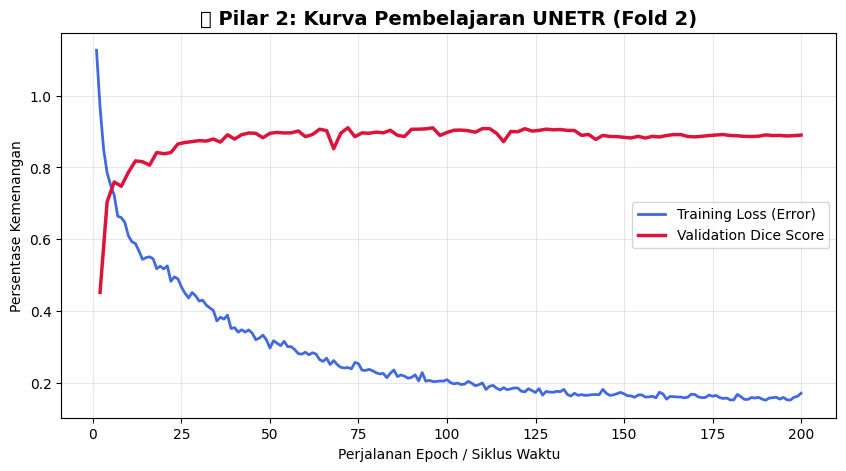

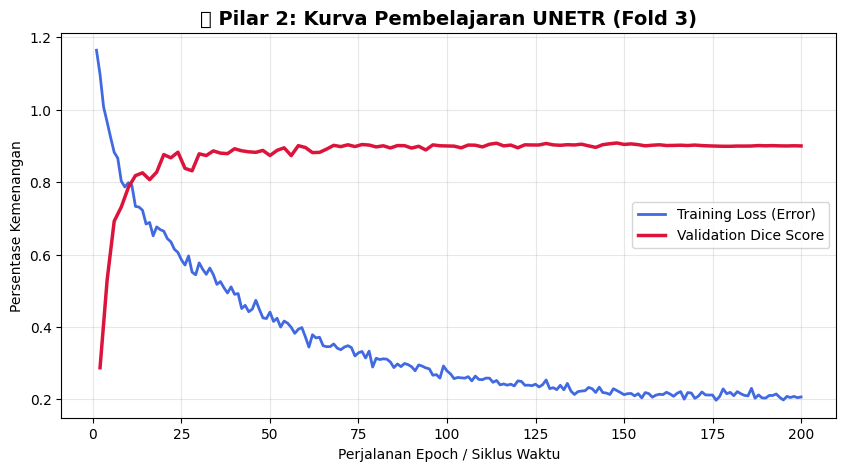

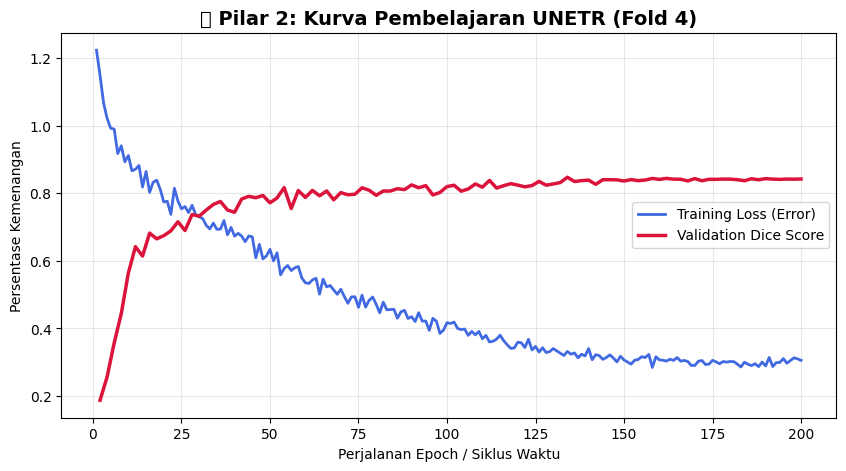

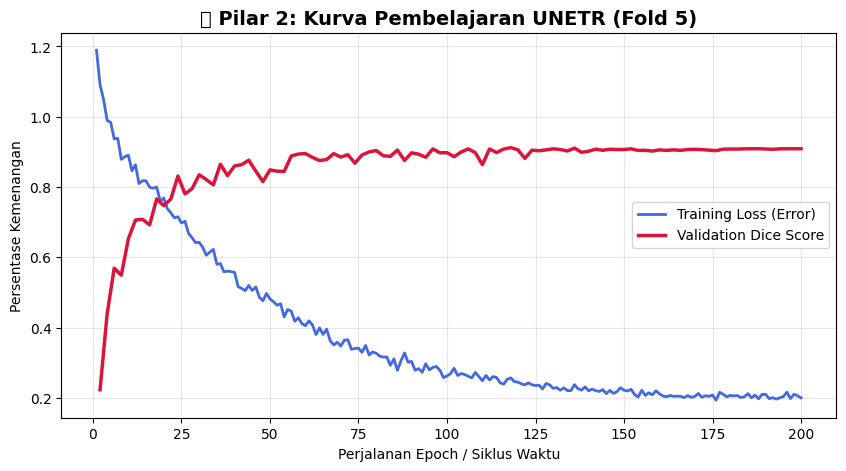

In [20]:
import matplotlib.pyplot as plt

print("🖨️ Mencetak Kurva")

# Mesin Plotting akan muterin kelima brankas Fold lu satu per satu dari RAM
for fold_num, data in fold_results.items():
    plt.figure(figsize=(10, 5))
    plt.title(f"📈 Pilar 2: Kurva Pembelajaran UNETR (Fold {fold_num})", fontsize=14, fontweight='bold')

    # Tarik data dari memori RAM (Dictionary fold_results)
    loss_list = data["train_loss"]
    dice_list = data["val_dice"]
    epoch_list = data["val_epochs"]

    # 1. Garis Loss Latihan Biru (Makin turun makin pinter)
    plt.plot(range(1, len(loss_list) + 1), loss_list, label="Training Loss (Error)", color="royalblue", linewidth=2)

    # 2. Garis Dice Validasi Merah (Makin naik makin akurat)
    plt.plot(epoch_list, dice_list, label="Validation Dice Score", color="crimson", linewidth=2.5)

    plt.xlabel(f"Perjalanan Epoch / Siklus Waktu")
    plt.ylabel("Persentase Kemenangan")
    plt.legend(loc="center right")
    plt.grid(alpha=0.3)

    # Auto-save ke direktori aktif / Drive biar aman buat dilampirkan ke Skripsi
    plt.savefig(f"/content/Pilar2_Curve_Fold{fold_num}.png", dpi=300)

    plt.show()


# One by One Model Test

In [21]:
import torch
import os
import numpy as np
from scipy import ndimage as ndi
from monai.networks.nets import UNETR
from monai.metrics import ConfusionMatrixMetric
from monai.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

print("AUDIT INDIVIDUAL (5 Model Evaluasi Sendiri-Sendiri di 20 Pasien Test)\n")

# Bikin DataLoader Spesifik HANYA UNTUK ARRAY test_pairs (20 Pasien Murni)
test_files = [
    {"image": os.path.join("processed", f[0].replace(".dcm", ".npy")),
     "label": os.path.join("processed", f[1].replace(".nii.gz", ".npy").replace(".nii", ".npy"))}
    for f in test_pairs
]
test_dataset = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Siapin buku rapor kosong buat nyatet nilai ujian 5 Fold
oof_f1, oof_iou, oof_acc, oof_sen, oof_spe = [], [], [], [], []

for fold in range(1, 6):
    print(f"🔄 Menatar Mesin Otak Fold {fold}/5 Membedah 20 Pasien...")

    # Bangun Model yang bersangkutan dari kasur GDrive
    m = UNETR(
        in_channels=1, out_channels=1, img_size=(96, 96, 96),
        feature_size=16, hidden_size=768, mlp_dim=3072, num_heads=12,
        norm_name="instance", res_block=True, dropout_rate=0.0,
    ).to(device)

    state_dict = torch.load(os.path.join(TEMP_MODEL_DIR, f"fold{fold}_best.pth"))
    clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    m.load_state_dict(clean_state_dict)
    m.eval()

    # Direset jadi Nol setiap Ganti Pasien di Fold Yang Sama
    conf_metric = ConfusionMatrixMetric(
        metric_name=["f1 score", "ts", "accuracy", "sensitivity", "specificity"],
        compute_sample=True, reduction="mean", get_not_nans=False
    )

    with torch.no_grad():
        # Masukin 20 Pasien dari Brankas Ujian (Bukan Pasien Val di dalem Fold)
        for data in test_loader:
            inputs = data["image"].to(device)
            labels = data["label"].to(device)

            # Nebak tipe polos jujur tanpa bantuan yang lain atau TTA
            pred = m(inputs).sigmoid()
            pred_mask = (pred > 0.5).float()

            # Masukin ke kalkulator
            conf_metric(y_pred=pred_mask, y=labels)

    # 4. Catet & Print nilai akhir Mesin Fold ini
    results = conf_metric.aggregate()
    oof_f1.append(results[0].item())
    oof_iou.append(results[1].item())
    oof_acc.append(results[2].item())
    oof_sen.append(results[3].item())
    oof_spe.append(results[4].item())

    print(f"   => Lulus Ujian! Dice: {results[0].item():.4f} | IoU: {results[1].item():.4f}\n")

# HITUNG RATA-RATA KAPASITAS MURNI 5 MODEL INDIVIDU (Average Score)
print(f"{'='*60}")
print("🏆 KESIMPULAN STABILITAS MESIN INDIVIDU (RATA-RATA 5 MODEL)")
print(f"{'='*60}")
print(f"   🎲 Rata-Rata Dice Score (F1) : {np.mean(oof_f1):.4f} ± {np.std(oof_f1):.4f}")
print(f"   📐 Rata-Rata IoU Score       : {np.mean(oof_iou):.4f} ± {np.std(oof_iou):.4f}")
print(f"   🎯 Rata-Rata Accuracy        : {np.mean(oof_acc):.4f} ± {np.std(oof_acc):.4f}")
print(f"   👁️ Rata-Rata Sensitivity     : {np.mean(oof_sen):.4f} ± {np.std(oof_sen):.4f}")
print(f"   🛡️ Rata-Rata Specificity     : {np.mean(oof_spe):.4f} ± {np.std(oof_spe):.4f}")
print(f"{'='*60}")


AUDIT INDIVIDUAL (5 Model Evaluasi Sendiri-Sendiri di 20 Pasien Test)

🔄 Menatar Mesin Otak Fold 1/5 Membedah 20 Pasien...
   => Lulus Ujian! Dice: 0.9067 | IoU: 0.8315

🔄 Menatar Mesin Otak Fold 2/5 Membedah 20 Pasien...
   => Lulus Ujian! Dice: 0.8981 | IoU: 0.8176

🔄 Menatar Mesin Otak Fold 3/5 Membedah 20 Pasien...
   => Lulus Ujian! Dice: 0.9065 | IoU: 0.8315

🔄 Menatar Mesin Otak Fold 4/5 Membedah 20 Pasien...
   => Lulus Ujian! Dice: 0.9014 | IoU: 0.8221

🔄 Menatar Mesin Otak Fold 5/5 Membedah 20 Pasien...
   => Lulus Ujian! Dice: 0.9106 | IoU: 0.8379

🏆 KESIMPULAN STABILITAS MESIN INDIVIDU (RATA-RATA 5 MODEL)
   🎲 Rata-Rata Dice Score (F1) : 0.9046 ± 0.0044
   📐 Rata-Rata IoU Score       : 0.8281 ± 0.0073
   🎯 Rata-Rata Accuracy        : 0.9971 ± 0.0001
   👁️ Rata-Rata Sensitivity     : 0.9260 ± 0.0132
   🛡️ Rata-Rata Specificity     : 0.9984 ± 0.0003


# Ensemble Evaluation

In [23]:
import torch
import os
import numpy as np
from scipy import ndimage as ndi
from monai.networks.nets import UNETR
from monai.metrics import ConfusionMatrixMetric
from monai.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🛠 FUNGSI BEDAH: LARGEST CONNECTED COMPONENT
def largest_connected_component(mask_3d):
    labeled, num_features = ndi.label(mask_3d)
    if num_features == 0: return mask_3d
    sizes = ndi.sum(mask_3d, labeled, range(1, num_features + 1))
    largest_label = np.argmax(sizes) + 1
    return (labeled == largest_label).astype(np.float32)

# 🧠 LOAD 5 OTAK AI UNETR KE DALAM RAM
models = []
for fold in range(1, 6):
    m = UNETR(
        in_channels=1, out_channels=1, img_size=(96, 96, 96),
        feature_size=16, hidden_size=768, mlp_dim=3072, num_heads=12,
        norm_name="instance", res_block=True, dropout_rate=0.0,
    ).to(device)

    # Load bobot yang udah lu latih di A100/L4
    state_dict = torch.load(os.path.join(TEMP_MODEL_DIR, f"fold{fold}_best.pth"))
    clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    m.load_state_dict(clean_state_dict)

    m.eval()
    models.append(m)
print("✅ Ke-5 Mesin Otak AI Berhasil Dihidupkan!")

# 🕵️ MEMBUKA BRANKAS 20 PASIEN UJIAN TERSEMBUNYI (HIDDEN TEST SET)
print("20 Pasien Hiden Test Set\n")

# Bikin DataLoader Spesifik HANYA UNTUK ARRAY test_pairs (20 Pasien Murni)
test_files = [
    {"image": os.path.join("processed", f[0].replace(".dcm", ".npy")),
     "label": os.path.join("processed", f[1].replace(".nii.gz", ".npy").replace(".nii", ".npy"))}
    for f in test_pairs
]
test_dataset = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 🏆 INISIALISASI MESIN KALKULATOR KOMBO 5 MULTI-METRIK
conf_metric = ConfusionMatrixMetric(
    metric_name=["f1 score", "ts", "accuracy", "sensitivity", "specificity"],
    compute_sample=True, reduction="mean", get_not_nans=False
)

print("⏳ Mengeksekusi Fusi Ensemble (5 Model) + Test-Time Augmentation (TTA)...")
with torch.no_grad():
    # ⚠️ PERHATIKAN: Sekarang mesin ujian muternya di `test_loader`
    for data in test_loader:
        inputs = data["image"].to(device)
        labels = data["label"].to(device)

        ensemble_preds = []
        for m in models:
            # 1. Tebakan Tipe A (Sudut Pandang Normal)
            pred_normal = m(inputs).sigmoid()

            # 2. Tebakan Tipe B (TTA Inovatif: Pasien Dibalik)
            inputs_flipped = torch.flip(inputs, dims=[2])
            pred_flipped = m(inputs_flipped).sigmoid()
            pred_unflipped = torch.flip(pred_flipped, dims=[2]) # Dibalik normal lagi

            # Sudut pandang Tipe A & Tipe B (Rata-rata TTA)
            pred_tta = (pred_normal + pred_unflipped) / 2.0
            ensemble_preds.append(pred_tta)

        # 🤝 KEPUTUSAN VOTING BERSAMA (Rata-rata dari 5 Model)
        final_prob = torch.mean(torch.stack(ensemble_preds), dim=0)
        final_mask = (final_prob > 0.5).float()

        # 🔪 POST-PROCESSING (Largest Connected Component)
        final_mask_np = largest_connected_component(final_mask[0, 0].cpu().numpy())
        final_tensor = torch.tensor(final_mask_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        # Masukan Masker Medis ke Mesin Evaluasi Penilai
        conf_metric(y_pred=final_tensor, y=labels)

# 📈 PANEN HASIL AKHIR (DARI 20 PASIEN BARU)
results = conf_metric.aggregate()
f1  = results[0].item()  # Dalam medis: Nilai F1 ekuivalen Matematik dengan Dice Score
iou = results[1].item()
acc = results[2].item()
sen = results[3].item()
spe = results[4].item()

print(f"\n{'='*65}")
print("🏆 HASIL AKHIR EVALUASI (ENSEMBLE 5 FOLD + TTA + LCC Pada 20 Pasien Baru)")
print(f"{'='*65}")
print(f"   🎲 Dice Score (F1) : {f1:.4f}")
print(f"   📐 IoU Score       : {iou:.4f}")
print(f"   🎯 Accuracy        : {acc:.4f}")
print(f"   👁️ Sensitivity     : {sen:.4f}")
print(f"   🛡️ Specificity     : {spe:.4f}")
print(f"{'='*65}")
print("🔥 Selesai! 🔥")

✅ Ke-5 Mesin Otak AI Berhasil Dihidupkan!
20 Pasien Hiden Test Set

⏳ Mengeksekusi Fusi Ensemble (5 Model) + Test-Time Augmentation (TTA)...

🏆 HASIL AKHIR EVALUASI (ENSEMBLE 5 FOLD + TTA + LCC Pada 20 Pasien Baru)
   🎲 Dice Score (F1) : 0.9095
   📐 IoU Score       : 0.8360
   🎯 Accuracy        : 0.9972
   👁️ Sensitivity     : 0.9302
   🛡️ Specificity     : 0.9985
🔥 Selesai! 🔥


🔍 MEMBEDAH 5 PASIEN DARI BRANKAS UJIAN (UNSEEN DATA)...


/tmp/ipykernel_73193/3626804684.py:62: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_73193/3626804684.py:62: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_73193/3626804684.py:62: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_73193/3626804684.py:62: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_73193/3626804684.py:62: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


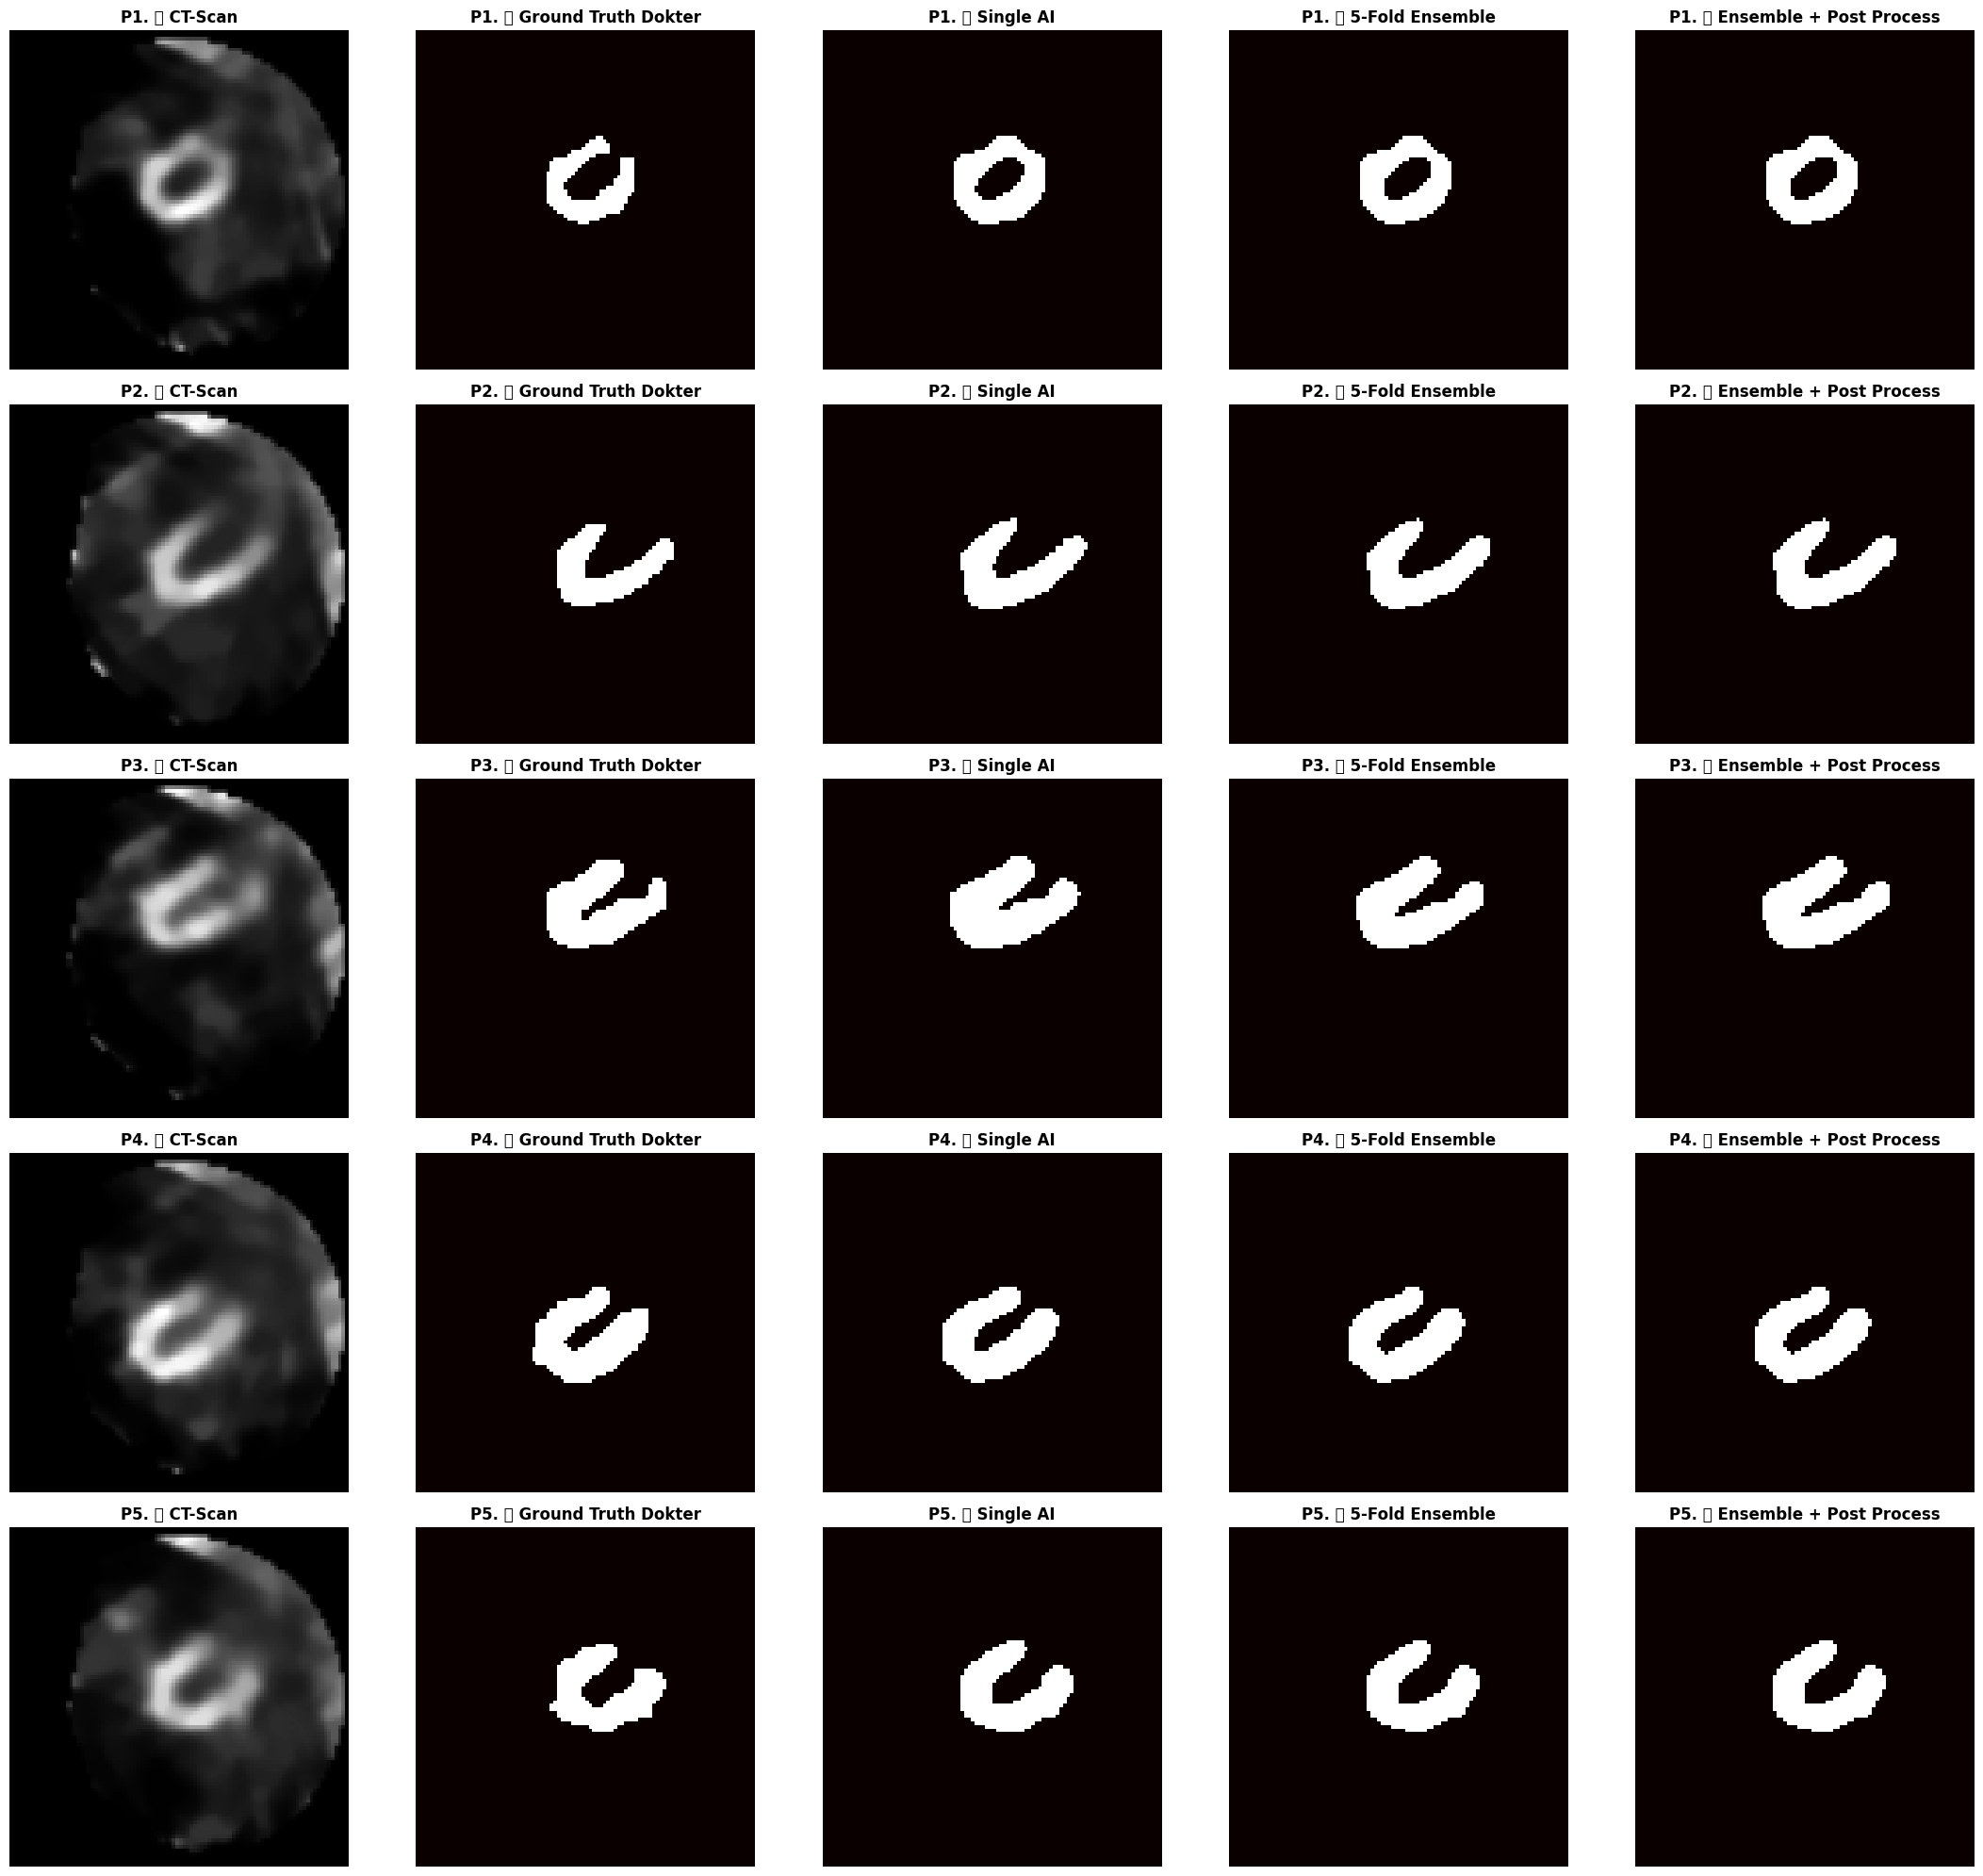

In [28]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 🌟 MAU TAMPILIN BERAPA PASIEN SEKALIGUS? (Tulis di sini)
num_samples = 5
z = 48  # Irisan daging 2D tepat di sumbu perut tengah

count = 0 # Mesin absen penahan rem
plt.figure(figsize=(22, 4 * num_samples)) # Kanvas otomatis manjang ke bawah

print(f"🔍 MEMBEDAH {num_samples} PASIEN DARI BRANKAS UJIAN (UNSEEN DATA)...")

with torch.no_grad():
    for data in test_loader:
        # Rem otomatis kalau absen udah nyampe kuota
        if count >= num_samples:
            break

        inputs = data["image"].to(device)
        labels = data["label"].to(device)

        # 1. Tebakan AI Anak Bawang (Murni Fold 1)
        single_out = models[0](inputs).sigmoid()
        single_mask = (single_out > 0.5).float()

        # 2. Tebakan THE AVENGERS (Gabungan 5 Fold)
        all_preds = [m(inputs).sigmoid() for m in models]
        ens_prob = torch.mean(torch.stack(all_preds), dim=0)
        ens_mask = (ens_prob > 0.5).float()

        # 3. Hasil Pembersihan Debu Kuman (LCC)
        pp = largest_connected_component(ens_mask[0, 0].cpu().numpy())

        # Ambil wujud daging irisan NumPy 2D dari Pasien ke-%
        img = inputs[0, 0].cpu().numpy()[:, :, z]
        gt = labels[0, 0].cpu().numpy()[:, :, z]
        sg = single_mask[0, 0].cpu().numpy()[:, :, z]
        en = ens_mask[0, 0].cpu().numpy()[:, :, z]
        po = pp[:, :, z]

        titles = [
            f"P{count+1}. 📸 CT-Scan",
            f"P{count+1}. 🩻 Ground Truth Dokter",
            f"P{count+1}. 🤖 Single AI",
            f"P{count+1}. 🧬 5-Fold Ensemble",
            f"P{count+1}. ⭐ Ensemble + Post Process"
        ]
        images = [img, gt, sg, en, po]
        cmaps = ["gray", "hot", "hot", "hot", "hot"]

        # Jejerin jadi 5 Kolom ke samping buat pasien ini
        for j in range(5):
            # Rumus Aljabar penempatan Koordinat Grafik
            plt.subplot(num_samples, 5, count * 5 + j + 1)
            plt.title(titles[j], fontsize=12, fontweight='bold')
            plt.imshow(images[j], cmap=cmaps[j])
            plt.axis("off")

        count += 1

plt.tight_layout()
plt.show()


🧊 MENGANGKAT 1 PASIEN UJIAN KE RUANG HOLOGRAM 3D...


/tmp/ipykernel_73193/1277833515.py:38: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_73193/1277833515.py:38: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


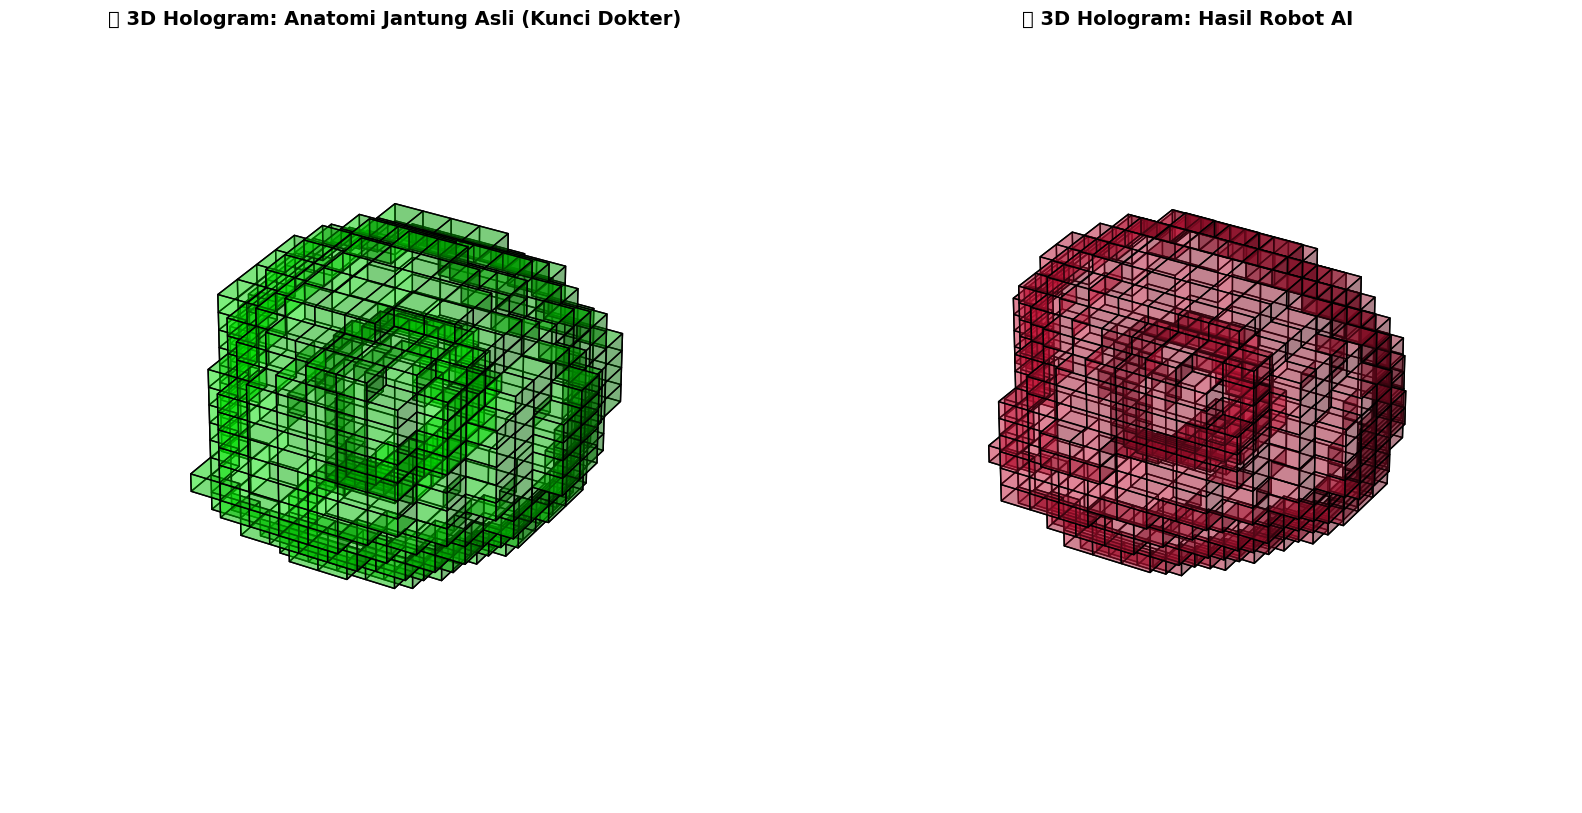

In [27]:
import matplotlib.pyplot as plt
import torch

print("🧊 MENGANGKAT 1 PASIEN UJIAN KE RUANG HOLOGRAM 3D...")

# 1. Panggil ulang 1 pasien acak dari brankas secara mandiri
with torch.no_grad():
    for data in test_loader:
        inputs = data["image"].to(device)
        labels = data["label"].to(device)

        # Nebak versi The Avengers (Ensemble)
        all_preds = [m(inputs).sigmoid() for m in models]
        ens_prob = torch.mean(torch.stack(all_preds), dim=0)
        ens_mask = (ens_prob > 0.5).float()

        # Ekstrak Wujud 3D Murni (Belum Diiris!)
        gt_3d = labels[0, 0].cpu().numpy()
        pp_3d = largest_connected_component(ens_mask[0, 0].cpu().numpy())

        break # Ambil 1 pasien yang pertama nongol langsung Cabut!

# 2. PROSES CETAK HOLOGRAM
fig = plt.figure(figsize=(16, 8))

# Kiri: 3D Topeng Asli
ax1 = fig.add_subplot(121, projection='3d')
ax1.voxels(gt_3d[::2, ::2, ::2], facecolors='lime', edgecolor='k', alpha=0.3)
ax1.set_title("🟢 3D Hologram: Anatomi Jantung Asli (Kunci Dokter)", fontsize=14, fontweight='bold')
ax1.axis('off')

# Kanan: 3D Topeng Tebakan AI
ax2 = fig.add_subplot(122, projection='3d')
ax2.voxels(pp_3d[::2, ::2, ::2], facecolors='crimson', edgecolor='k', alpha=0.3)
ax2.set_title("🔴 3D Hologram: Hasil Robot AI", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()
